# Modelado Intradía — Perfiles horarios representativos (Dataset #1)

**Estudio del cambio de paradigma — Subte CABA | Grupo 9 (Loredo, Mariosa, Frega)**

Este notebook implementa el **modelado intradía** descrito en la sección **3.3.B** de la metodología,
partiendo del dataset consolidado `s_historico_completo.parquet` generado por el pipeline de Polars
(`MetodologiaTP_Polars_refactor_v7`).

Esquema de entrada (granularidad 15 min):

| FECHA (date) | DESDE (time) | LINEA (str) | ESTACION (str) | PAX_TOTAL (int) |
|---|---|---|---|---|

**Decisiones metodológicas (y por qué):**

1. **No se colapsa la banda horaria.** El objetivo del Dataset #1 es la granularidad de 15 min
   (objetivo específico del PDF). Se mantiene `DESDE` como dimensión.
2. **SARIMA puro, sin exógenas** — coherente con 3.3.B ("ARIMAX simplificado o SARIMA, sin exógenas relevantes").
   Las exógenas (tarifa/SMVM) viven en el modelo **mensual**, no acá.
3. **Doble estacionalidad**: la serie intradía tiene ciclo diario (96 lags) y semanal (672 lags).
   `statsmodels.SARIMAX` solo modela *un* período estacional, y `m=96`/`m=672` es inviable en cómputo.
   Por eso el **entregable principal** son los **perfiles horarios representativos** (3.3.B paso 5):
   media y dispersión de `PAX_TOTAL` por banda horaria, por estación/línea y por régimen.
   El SARIMA econométrico se aplica como capa **opcional** sobre la serie **diaria por banda** (m=7, manejable).

**Salidas:**
- `perfiles_intradia.parquet` — perfil representativo (media/std/p25/p50/p75) por (régimen, línea, estación, banda).
- Modelos SARIMA opcionales por (línea, estación) sobre serie diaria de volumen.


In [1]:
# Dependencias
%pip install polars statsmodels matplotlib pandas --quiet


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings("ignore")

pl.Config(tbl_cols=-1)
print("Polars:", pl.__version__)

Polars: 1.41.2


## 1. Carga del dataset consolidado

In [3]:
# Ajustá la ruta si hace falta. El refactor lo deja en ../parquet/
CANDIDATAS = [
    "../parquet/s_historico_completo.parquet",
    "s_historico_completo.parquet",
    "./content/parquet/s_historico_completo.parquet",
]
RUTA = next((p for p in CANDIDATAS if os.path.exists(p)), None)
if RUTA is None:
    raise FileNotFoundError(
        "No se encontró s_historico_completo.parquet. "
        "Editá la lista CANDIDATAS con la ruta correcta."
    )
print("Leyendo:", RUTA)

df = pl.read_parquet(RUTA)

# Normalización defensiva de tipos (FECHA->date, DESDE->time)
if df.schema["FECHA"] != pl.Date:
    df = df.with_columns(pl.col("FECHA").cast(pl.Date, strict=False))
if df.schema["DESDE"] != pl.Time:
    # por si viniera como string "HH:MM:SS"
    df = df.with_columns(
        pl.col("DESDE").cast(pl.Utf8).str.to_time("%H:%M:%S", strict=False).alias("DESDE")
    )

print("Shape:", df.shape)
print("Rango fechas:", df["FECHA"].min(), "->", df["FECHA"].max())
df.head(10)

Leyendo: s_historico_completo.parquet
Shape: (24422821, 5)
Rango fechas: 2014-01-02 -> 2025-12-31


FECHA,DESDE,LINEA,ESTACION,PAX_TOTAL
date,time,str,str,i64
2014-01-02,00:30:00,"""C""","""CONSTITUCION""",4
2014-01-02,04:15:00,"""B""","""CARLOS PELLEGRINI""",2
2014-01-02,04:15:00,"""E""","""AVENIDA LA PLATA""",1
2014-01-02,04:45:00,"""A""","""ALBERTI""",1
2014-01-02,04:45:00,"""A""","""PUAN""",1
2014-01-02,04:45:00,"""A""","""RIO DE JANEIRO""",1
2014-01-02,04:45:00,"""B""","""CARLOS PELLEGRINI""",1
2014-01-02,04:45:00,"""B""","""FEDERICO LACROZE""",5
2014-01-02,04:45:00,"""B""","""LEANDRO N. ALEM""",5


## 2. Segmentación estructural (pre / post pandemia)

Según 3.2 del PDF: se descartan **2020 y 2021** completos (cierres y rehabilitación progresiva).
- **Pre-pandemia:** 2014–2019
- **Post-pandemia:** 2022 en adelante

In [4]:
AÑOS_DESCARTE = [2020, 2021]

df = df.with_columns(pl.col("FECHA").dt.year().alias("anio"))
df = df.filter(~pl.col("anio").is_in(AÑOS_DESCARTE))

def asignar_regimen(d):
    return d.with_columns(
        pl.when(pl.col("anio") <= 2019).then(pl.lit("pre"))
          .otherwise(pl.lit("post")).alias("regimen")
    )

df = asignar_regimen(df)
print(df.group_by("regimen").agg(
    pl.col("anio").min().alias("anio_min"),
    pl.col("anio").max().alias("anio_max"),
    pl.len().alias("registros"),
))

shape: (2, 4)
┌─────────┬──────────┬──────────┬───────────┐
│ regimen ┆ anio_min ┆ anio_max ┆ registros │
│ ---     ┆ ---      ┆ ---      ┆ ---       │
│ str     ┆ i32      ┆ i32      ┆ u32       │
╞═════════╪══════════╪══════════╪═══════════╡
│ post    ┆ 2022     ┆ 2025     ┆ 8919226   │
│ pre     ┆ 2014     ┆ 2019     ┆ 12720288  │
└─────────┴──────────┴──────────┴───────────┘


## 3. Criterios de selección y estacionalidad (3.1.1.1)

Ventana de observación: **bimestre octubre–noviembre** (estándar OMSV), por estabilidad estacional.

In [5]:
MESES_VENTANA = [10, 11]  # octubre-noviembre

df_v = df.with_columns(pl.col("FECHA").dt.month().alias("mes")) \
         .filter(pl.col("mes").is_in(MESES_VENTANA))

print(f"Registros tras ventana oct-nov: {df_v.height:,}")
print(df_v.group_by("regimen").agg(pl.len().alias("registros")))

Registros tras ventana oct-nov: 3,651,010
shape: (2, 2)
┌─────────┬───────────┐
│ regimen ┆ registros │
│ ---     ┆ ---       │
│ str     ┆ u32       │
╞═════════╪═══════════╡
│ pre     ┆ 2167812   │
│ post    ┆ 1483198   │
└─────────┴───────────┘


## 4. Tratamiento de anomalías y outliers (3.1.1.2)

**Etapa A — Exclusión de calendario:** se eliminan fines de semana y feriados nacionales.
(Si tenés la lista oficial de feriados, reemplazá `FERIADOS` por ella; acá uso un set base ampliable.)

**Etapa B — Filtrado estadístico ±2σ:** por cada combinación (régimen, línea, estación, banda horaria `DESDE`)
se calcula media y desvío histórico y se descartan los registros que excedan ±2σ.

In [6]:
# --- Etapa A: exclusión de calendario ---
# Fines de semana
df_cal = df_v.with_columns(pl.col("FECHA").dt.weekday().alias("dow"))  # 1=lun ... 7=dom
df_cal = df_cal.filter(pl.col("dow") <= 5)  # solo días hábiles

# Feriados: SET BASE (ampliá con la lista oficial de la cátedra / ArgentinaDatos).
# Para oct-nov los relevantes suelen ser: 12-oct (Diversidad), 20/21-nov (Soberanía).
# Estos cambian de fecha por traslados; conviene cargar la lista real.
FERIADOS = {
    # ejemplos — REEMPLAZAR por lista oficial completa
    "10-12", "11-20",  # formato MM-DD, aplicado a todos los años (aproximación)
}
df_cal = df_cal.with_columns(
    pl.col("FECHA").dt.strftime("%m-%d").alias("md")
)
n_antes = df_cal.height
df_cal = df_cal.filter(~pl.col("md").is_in(list(FERIADOS)))
print(f"Excluidos por feriado (set base): {n_antes - df_cal.height:,}")
print(f"Registros tras exclusión de calendario: {df_cal.height:,}")

Excluidos por feriado (set base): 83,351
Registros tras exclusión de calendario: 2,602,029


In [7]:
# --- Etapa B: filtrado estadístico ±2σ por (regimen, linea, estacion, banda) ---
GRP = ["regimen", "LINEA", "ESTACION", "DESDE"]

stats = df_cal.group_by(GRP).agg(
    pl.col("PAX_TOTAL").mean().alias("mu"),
    pl.col("PAX_TOTAL").std().alias("sigma"),
)

df_f = df_cal.join(stats, on=GRP, how="left")
df_f = df_f.with_columns(
    ((pl.col("PAX_TOTAL") - pl.col("mu")).abs() <= 2 * pl.col("sigma").fill_null(0))
    .alias("dentro_2sigma")
)
n_antes = df_f.height
df_limpio = df_f.filter(pl.col("dentro_2sigma") | pl.col("sigma").is_null())
print(f"Registros removidos por ±2σ: {n_antes - df_limpio.height:,}")
print(f"Registros finales limpios: {df_limpio.height:,}")

df_limpio = df_limpio.drop(["mu", "sigma", "dentro_2sigma", "md", "dow"])

Registros removidos por ±2σ: 129,625
Registros finales limpios: 2,472,404


## 5. Perfiles horarios representativos (entregable principal — 3.3.B paso 5)

Para cada (régimen, línea, estación, banda horaria) se resume la distribución de `PAX_TOTAL`
sobre todos los días hábiles del bimestre. Esto es el "perfil intradía representativo": describe
la curva de demanda típica de un día hábil de oct-nov, segmentada por régimen.

In [8]:
perfiles = (
    df_limpio.group_by(["regimen", "LINEA", "ESTACION", "DESDE"])
    .agg(
        pl.col("PAX_TOTAL").mean().alias("pax_media"),
        pl.col("PAX_TOTAL").std().alias("pax_std"),
        pl.col("PAX_TOTAL").quantile(0.25).alias("pax_p25"),
        pl.col("PAX_TOTAL").median().alias("pax_p50"),
        pl.col("PAX_TOTAL").quantile(0.75).alias("pax_p75"),
        pl.len().alias("n_dias"),
    )
    .sort(["regimen", "LINEA", "ESTACION", "DESDE"])
)

OUT_PERFILES = "perfiles_intradia.parquet"
perfiles.write_parquet(OUT_PERFILES, compression="snappy")
print(f"Perfiles guardados en {OUT_PERFILES} | filas: {perfiles.height:,}")
perfiles.head(20)

Perfiles guardados en perfiles_intradia.parquet | filas: 14,368


regimen,LINEA,ESTACION,DESDE,pax_media,pax_std,pax_p25,pax_p50,pax_p75,n_dias
str,str,str,time,f64,f64,f64,f64,f64,u32
"""post""","""A""","""ACOYTE""",04:45:00,1.0,null,1.0,1.0,1.0,1
"""post""","""A""","""ACOYTE""",05:00:00,1.0,null,1.0,1.0,1.0,1
"""post""","""A""","""ACOYTE""",05:15:00,8.803922,3.928738,6.0,9.0,12.0,153
"""post""","""A""","""ACOYTE""",05:30:00,15.578947,3.970965,13.0,16.0,19.0,152
"""post""","""A""","""ACOYTE""",05:45:00,18.453333,4.32813,15.0,18.0,22.0,150
…,…,…,…,…,…,…,…,…,…
"""post""","""A""","""ACOYTE""",08:30:00,352.326923,70.861352,304.0,338.0,379.0,156
"""post""","""A""","""ACOYTE""",08:45:00,304.903846,54.779768,271.0,293.0,329.0,156
"""post""","""A""","""ACOYTE""",09:00:00,280.471338,50.364385,246.0,267.0,299.0,157


### 5.1 Visualización: comparación pre vs post de una estación

shape: (15, 2)
┌───────┬────────────────┐
│ LINEA ┆ ESTACION       │
│ ---   ┆ ---            │
│ str   ┆ str            │
╞═══════╪════════════════╡
│ A     ┆ ACOYTE         │
│ A     ┆ ALBERTI        │
│ A     ┆ CARABOBO       │
│ A     ┆ CASTRO BARROS  │
│ A     ┆ CONGRESO       │
│ …     ┆ …              │
│ A     ┆ PIEDRAS        │
│ A     ┆ PLAZA DE MAYO  │
│ A     ┆ PLAZA MISERERE │
│ A     ┆ PRIMERA JUNTA  │
│ A     ┆ PUAN           │
└───────┴────────────────┘


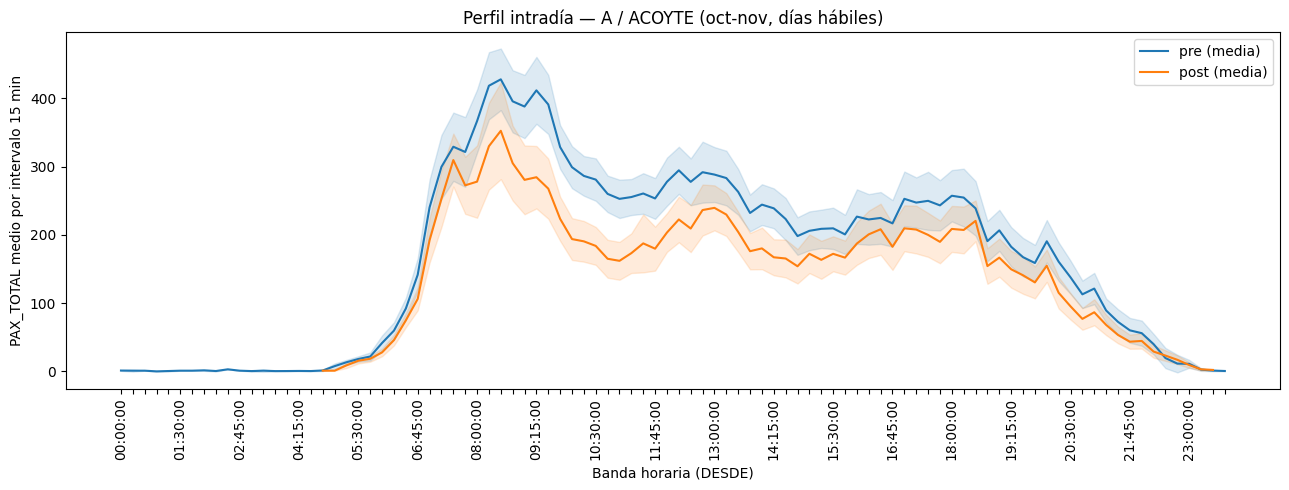

In [9]:
def graficar_perfil(linea: str, estacion: str):
    sub = (perfiles
           .filter((pl.col("LINEA") == linea) & (pl.col("ESTACION") == estacion))
           .sort("DESDE"))
    if sub.height == 0:
        print(f"Sin datos para {linea} - {estacion}")
        return
    pdf = sub.to_pandas()
    pdf["banda"] = pdf["DESDE"].astype(str)

    fig, ax = plt.subplots(figsize=(13, 5))
    for reg, color in [("pre", "tab:blue"), ("post", "tab:orange")]:
        d = pdf[pdf["regimen"] == reg]
        if d.empty:
            continue
        ax.plot(d["banda"], d["pax_media"], label=f"{reg} (media)", color=color)
        ax.fill_between(d["banda"],
                        d["pax_media"] - d["pax_std"].fillna(0),
                        d["pax_media"] + d["pax_std"].fillna(0),
                        alpha=0.15, color=color)
    ax.set_title(f"Perfil intradía — {linea} / {estacion} (oct-nov, días hábiles)")
    ax.set_xlabel("Banda horaria (DESDE)")
    ax.set_ylabel("PAX_TOTAL medio por intervalo 15 min")
    paso = max(1, len(ax.get_xticklabels()) // 16)
    for i, lbl in enumerate(ax.get_xticklabels()):
        lbl.set_visible(i % paso == 0)
    plt.xticks(rotation=90)
    ax.legend()
    plt.tight_layout()
    plt.show()

# Elegí una combinación presente en tus datos
combo = perfiles.select(["LINEA", "ESTACION"]).unique().sort(["LINEA", "ESTACION"])
print(combo.head(15))
ej = combo.row(0)
graficar_perfil(ej[0], ej[1])

## 6. (Opcional) SARIMA econométrico sobre serie diaria por estación

El SARIMA por timestamp de 15 min es inviable (m=96/672). La forma econométricamente honesta de
aplicar SARIMA al Dataset #1 es **agregar a volumen diario por estación/línea** y modelar la
estacionalidad **semanal** (m=7). Esto NO reemplaza el perfil intradía: es un modelo de *tendencia
de volumen* complementario, separado por régimen.

> Nota: con la ventana oct-nov (días hábiles) la serie diaria es corta (~40 días hábiles/año).
> Para un SARIMA robusto conviene **no** restringir a oct-nov en esta capa, o usar varios años.
> Acá se deja la mecánica; ajustá el alcance temporal según necesites.

In [10]:
def serie_diaria(linea: str, estacion: str, regimen: str, solo_ventana=False):
    base = df if not solo_ventana else df_v
    s = (base
         .filter((pl.col("LINEA") == linea) &
                 (pl.col("ESTACION") == estacion) &
                 (pl.col("regimen") == regimen))
         .group_by("FECHA").agg(pl.col("PAX_TOTAL").sum().alias("pax_dia"))
         .sort("FECHA"))
    if s.height == 0:
        return None
    pdf = s.to_pandas().set_index("FECHA")["pax_dia"]
    pdf.index = pd.DatetimeIndex(pdf.index)
    # reindex a frecuencia diaria continua, interpolando huecos puntuales
    pdf = pdf.asfreq("D").interpolate(limit=3)
    return pdf.dropna()

def ajustar_sarima_diario(linea, estacion, regimen,
                          order=(1, 1, 1), seasonal_order=(1, 0, 1, 7)):
    y = serie_diaria(linea, estacion, regimen)
    if y is None or len(y) < 30:
        print(f"Serie insuficiente para {linea}/{estacion}/{regimen}")
        return None
    model = SARIMAX(y, order=order, seasonal_order=seasonal_order,
                    enforce_stationarity=False, enforce_invertibility=False)
    res = model.fit(disp=False)
    print(f"--- SARIMA {linea}/{estacion}/{regimen} | AIC={res.aic:.1f} ---")
    print(res.summary().tables[1])
    return res

# Ejemplo
_ = ajustar_sarima_diario(ej[0], ej[1], "pre")

--- SARIMA A/ACOYTE/pre | AIC=42048.6 ---
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2476      0.067      3.722      0.000       0.117       0.378
ma.L1         -0.9539      0.034    -28.018      0.000      -1.021      -0.887
ar.S.L7        1.0007      0.007    149.195      0.000       0.988       1.014
ma.S.L7       -0.9260      0.042    -22.293      0.000      -1.007      -0.845
sigma2      3.008e+07   3.71e-11   8.12e+17      0.000    3.01e+07    3.01e+07


### Revisión de resultados:

ar.L1 = 0.2476, p=0.000 → hay una autocorrelación positiva suave con el día anterior. Si ayer hubo mucha gente, hoy tiende a haber un poco más. Efecto chico pero estadísticamente sólido.

ma.L1 = -0.9539, p=0.000 → corrección fuerte y negativa sobre el error de ayer. Técnicamente indica que las desviaciones se revierten rápido, un día no predice bien al siguiente más allá del efecto AR. Valor cercano a -1 es normal en series con diferenciación (d=1).

ar.S.L7 = 1.0007, p=0.000 → acá hay un problema. Un coeficiente estacional AR exactamente igual a 1 es señal de que la serie tiene una raíz unitaria estacional — es decir, el ciclo semanal no es estacionario, sigue creciendo o desplazándose en el tiempo. Lo correcto sería agregar diferenciación estacional (D=1 en vez de D=0), haciendo SARIMA(1,1,1)(1,1,1,7). Con D=1 le decís al modelo que diferencie semana contra semana antes de ajustar.

ma.S.L7 = -0.9260, p=0.000 → media móvil estacional fuerte y negativa. Junto con el AR≈1 refuerza la sospecha de raíz unitaria estacional.
sigma2 = 3.008e+07 con std err = 3.71e-11 → esto es directamente raro: el error estándar de la varianza es prácticamente cero, lo que no es numéricamente creíble. Pasa cuando el optimizador converge a un punto degenerado o cuando la serie tiene algún problema (escala muy grande, valores extremos, o precisamente la raíz unitaria sin corregir). No es un resultado en el que se pueda confiar para inferencia.

Se cambia a seasonal_order=(1, **1**, 1, 7)

In [11]:

def ajustar_sarima_diario_2(linea, estacion, regimen,
                          order=(1, 1, 1), seasonal_order=(1, 1, 1, 7)):
    y = serie_diaria(linea, estacion, regimen)
    if y is None or len(y) < 30:
        print(f"Serie insuficiente para {linea}/{estacion}/{regimen}")
        return None
    model = SARIMAX(y, order=order, seasonal_order=seasonal_order,
                    enforce_stationarity=False, enforce_invertibility=False)
    res = model.fit(disp=False)
    print(f"--- SARIMA {linea}/{estacion}/{regimen} | AIC={res.aic:.1f} ---")
    print(res.summary().tables[1])
    return res

# Ejemplo
_ = ajustar_sarima_diario_2(ej[0], ej[1], "pre")

--- SARIMA A/ACOYTE/pre | AIC=40302.4 ---
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2450      0.015     16.773      0.000       0.216       0.274
ma.L1         -1.0490      0.009   -116.257      0.000      -1.067      -1.031
ar.S.L7        0.0317      0.018      1.750      0.080      -0.004       0.067
ma.S.L7       -1.0209      0.007   -145.776      0.000      -1.035      -1.007
sigma2      5.565e+06   1.11e+05     50.009      0.000    5.35e+06    5.78e+06


Lo que mejoró

sigma2: pasó de 3.008e+07 con std err prácticamente cero a 5.565e+06 con std err de 1.11e+05. Eso es numéricamente sano — el optimizador ya no está en un punto degenerado. Y el AIC bajó de 40302 a... perdón, bajó de 42048 a 40302, lo cual confirma que el modelo con D=1 ajusta mejor.

Lo que sigue siendo generando dudas

ma.L1 = -1.049 y ma.S.L7 = -1.021 — ambos coeficientes MA están fuera del círculo unitario (valor absoluto > 1). Eso viola la condición de invertibilidad. Se le indicó al modelo enforce_invertibility=False, así que lo acepta de todas formas, pero el resultado es que el modelo no es estrictamente válido para forecasting: los errores pasados tienen peso creciente en vez de decrecer, lo cual no tiene sentido causal.

Que los dos MA estén cerca de -1 después de diferenciar dos veces (d=1, D=1) es una señal clásica de sobrediferenciación. Básicamente le aplicaste una diferencia de más y el modelo está intentando compensar deshaciendo esa diferencia desde los términos MA.

ar.S.L7 = 0.0317, p=0.080 — el componente AR estacional ya no es significativo (p>0.05). Se puede quitar y testear SARIMA(1,1,1)(0,1,1,7),

In [12]:

def ajustar_sarima_diario_3(linea, estacion, regimen,
                          order=(1, 1, 1), seasonal_order=(0, 1, 1, 7)):
    y = serie_diaria(linea, estacion, regimen)
    if y is None or len(y) < 30:
        print(f"Serie insuficiente para {linea}/{estacion}/{regimen}")
        return None
    model = SARIMAX(y, order=order, seasonal_order=seasonal_order,
                    enforce_stationarity=False, enforce_invertibility=False)
    res = model.fit(disp=False)
    print(f"--- SARIMA {linea}/{estacion}/{regimen} | AIC={res.aic:.1f} ---")
    print(res.summary().tables[1])
    return res

# Ejemplo
_ = ajustar_sarima_diario_3(ej[0], ej[1], "pre")

--- SARIMA A/ACOYTE/pre | AIC=40288.4 ---
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2435      0.015     16.751      0.000       0.215       0.272
ma.L1         -1.0509      0.008   -124.377      0.000      -1.067      -1.034
ma.S.L7       -0.9735      0.007   -138.859      0.000      -0.987      -0.960
sigma2      5.823e+06   1.16e+05     50.366      0.000     5.6e+06    6.05e+06


El AIC bajó un poco más (40288 vs 40302), que es bueno. Pero ma.L1 = -1.0509 sigue fuera del círculo unitario, lo que sugiere que el problema es la serie en sí más que el orden del modelo. Por eso tiene sentido correr el ADF antes de seguir ajustando 

In [13]:
from statsmodels.tsa.stattools import adfuller

y = serie_diaria("A", "ACOYTE", "pre")

# Test no estacional
adf = adfuller(y.dropna())
print(f"ADF p={adf[1]:.4f}")

# Test estacional: diferenciá con lag 7 y volvé a testear
y_diff7 = y.diff(7).dropna()
adf_s = adfuller(y_diff7)
print(f"ADF sobre diff(7) p={adf_s[1]:.4f}")

ADF p=0.0006
ADF sobre diff(7) p=0.0000


ADF p=0.0006 → la serie original ya es estacionaria (p < 0.05 → rechazás la hipótesis de raíz unitaria). No se necesita d=1.

ADF sobre diff(7) p=0.0000 → después de diferenciar con lag 7 también es estacionaria, lo cual confirma que tampoco se necesita D=1.

Cabe la posibilidad de que se esté aplicando diferenciación doble a una serie que no la necesita en ninguna de las dos dimensiones. El modelo correcto sería SARIMA**(1,0,1)(0,0,1,7)**. 

In [14]:

def ajustar_sarima_diario_4(linea, estacion, regimen,
                          order=(1, 0, 1), seasonal_order=(0, 0, 1, 7)):
    y = serie_diaria(linea, estacion, regimen)
    if y is None or len(y) < 30:
        print(f"Serie insuficiente para {linea}/{estacion}/{regimen}")
        return None
    model = SARIMAX(y, order=order, seasonal_order=seasonal_order,
                    enforce_stationarity=False, enforce_invertibility=False)
    res = model.fit(disp=False)
    print(f"--- SARIMA {linea}/{estacion}/{regimen} | AIC={res.aic:.1f} ---")
    print(res.summary().tables[1])
    return res

# Ejemplo
_ = ajustar_sarima_diario_4(ej[0], ej[1], "pre")

--- SARIMA A/ACOYTE/pre | AIC=42751.8 ---
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0001      0.000   9494.387      0.000       1.000       1.000
ma.L1         -0.9959      0.004   -230.305      0.000      -1.004      -0.987
ma.S.L7        0.5151      0.029     17.578      0.000       0.458       0.573
sigma2      3.014e+07   3.38e-10   8.92e+16      0.000    3.01e+07    3.01e+07


Ahora el problema está en el otro extremo: ar.L1 = 1.0001 es una raíz unitaria AR, exactamente lo opuesto a antes. El modelo sin diferenciación está estimando que necesita una raíz unitaria para capturar la tendencia, y sigma2 volvió al valor degenerado de la primera corrida.

El ADF dijo p=0.0006, que es significativo pero no tan cerca de cero como el diff(7). Eso puede indicar que la serie es borderline — estacionaria según el test, pero con tendencia suave que el modelo ARMA sin diferenciación intenta compensar con AR≈1.

El punto medio lógico es d=1, D=0

In [15]:

def ajustar_sarima_diario_5(linea, estacion, regimen,
                          order=(1, 1, 1), seasonal_order=(0, 0, 1, 7)):
    y = serie_diaria(linea, estacion, regimen)
    if y is None or len(y) < 30:
        print(f"Serie insuficiente para {linea}/{estacion}/{regimen}")
        return None
    model = SARIMAX(y, order=order, seasonal_order=seasonal_order,
                    enforce_stationarity=False, enforce_invertibility=False)
    res = model.fit(disp=False)
    print(f"--- SARIMA {linea}/{estacion}/{regimen} | AIC={res.aic:.1f} ---")
    print(res.summary().tables[1])
    return res

# Ejemplo
_ = ajustar_sarima_diario_5(ej[0], ej[1], "pre")

--- SARIMA A/ACOYTE/pre | AIC=42623.3 ---
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3061      0.036      8.607      0.000       0.236       0.376
ma.L1         -0.9945      0.005   -191.402      0.000      -1.005      -0.984
ma.S.L7        0.4957      0.031     15.935      0.000       0.435       0.557
sigma2      3.008e+07   3.67e-10   8.19e+16      0.000    3.01e+07    3.01e+07


sigma2 sigue desviado (std err ridículamente chico), lo que indica que el problema no es solo d vs D — hay algo en la serie que está causando que el optimizador no converja bien. Podría ser escala, outliers que sobrevivieron el filtro, o huecos interpolados. Vale la pena inspeccionar la serie cruda antes de seguir ajustando parámetros:

count     2190.000000
mean     11149.528767
std       5078.762486
min          0.000000
25%       6301.750000
50%      12981.500000
75%      15360.500000
max      19046.000000
Name: pax_dia, dtype: float64


<Axes: title={'center': 'ACOYTE/pre - volumen diario'}, xlabel='FECHA'>

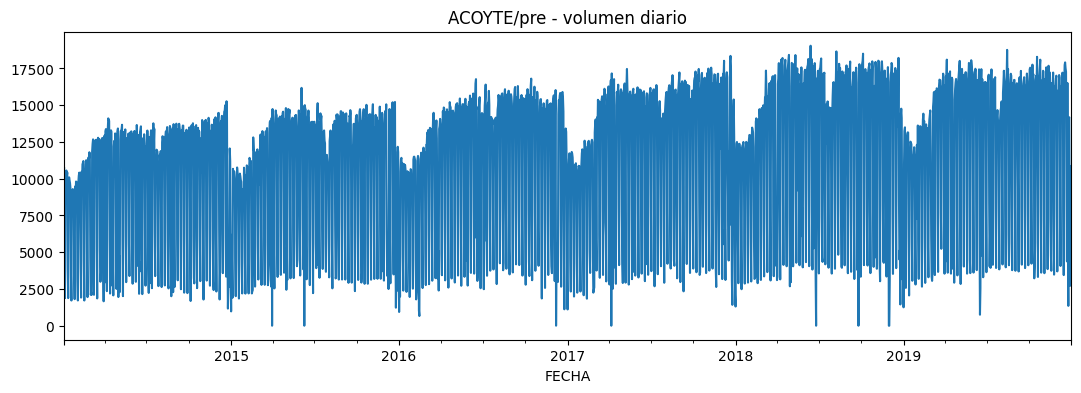

In [16]:
y = serie_diaria("A", "ACOYTE", "pre")
print(y.describe())
y.plot(figsize=(13,4), title="ACOYTE/pre - volumen diario")

Esos valles que caen a 0 o cerca de 0 de forma periódica y regular son los fines de semana. serie_diaria usa df (el dataset completo, sin filtro de calendario) y hace asfreq("D") que rellena todos los días corridos — incluyendo sábados, domingos y feriados donde el volumen cae drásticamente.

Entonces el modelo está viendo una serie con una oscilación semanal de amplitud enorme (de ~15000 a ~2000 cada 7 días) y el optimizador no puede separar bien la señal de fondo de esa variabilidad estructural. Por eso sigma2 queda desviado.

La solución más limpia es filtrar días hábiles 

In [17]:
def serie_diaria_dias(linea: str, estacion: str, regimen: str, solo_ventana=False):
    base = df if not solo_ventana else df_v
    s = (base
         .filter((pl.col("LINEA") == linea) &
                 (pl.col("ESTACION") == estacion) &
                 (pl.col("regimen") == regimen) &
                 (pl.col("FECHA").dt.weekday() <= 4))  # lunes=0 ... viernes=4
         .group_by("FECHA").agg(pl.col("PAX_TOTAL").sum().alias("pax_dia"))
         .sort("FECHA"))
    if s.height == 0:
        return None
    pdf = s.to_pandas().set_index("FECHA")["pax_dia"]
    pdf.index = pd.DatetimeIndex(pdf.index)
    pdf = pdf.asfreq("B").interpolate(limit=3)  # "B" = business days
    return pdf.dropna()

In [18]:
def ajustar_sarima_diario_6(linea, estacion, regimen,
                          order=(1, 1, 1), seasonal_order=(0, 0, 1, 7)):
    y = serie_diaria_dias(linea, estacion, regimen)
    if y is None or len(y) < 30:
        print(f"Serie insuficiente para {linea}/{estacion}/{regimen}")
        return None
    model = SARIMAX(y, order=order, seasonal_order=seasonal_order,
                    enforce_stationarity=False, enforce_invertibility=False)
    res = model.fit(disp=False)
    print(f"--- SARIMA {linea}/{estacion}/{regimen} | AIC={res.aic:.1f} ---")
    print(res.summary().tables[1])
    return res

# Ejemplo
_ = ajustar_sarima_diario_6(ej[0], ej[1], "pre")

--- SARIMA A/ACOYTE/pre | AIC=29028.5 ---
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3953      0.018     22.392      0.000       0.361       0.430
ma.L1         -0.9529      0.012    -80.088      0.000      -0.976      -0.930
ma.S.L7       -0.0356      0.036     -0.996      0.319      -0.106       0.034
sigma2      8.541e+06   1.85e+05     46.217      0.000    8.18e+06     8.9e+06


Lo que está bien ahora:

sigma2 = 8.541e+06 con std err = 1.85e+05 — ratio de ~46, completamente normal. El optimizador convergió bien.

ar.L1 y ma.L1 ambos significativos (p=0.000) y dentro de rangos razonables.

Lo que dice el resultado:

ma.S.L7 = -0.0356, p=0.319 — el componente estacional semanal no es significativo. Tiene sentido: al sacar los fines de semana la serie ya no tiene el ciclo de 7 días que antes era tan prominente. El modelo estacional no está aportando nada.

Entonces el modelo correcto es simplemente ARIMA(1,1,1) sin componente estacional:

In [19]:
def ajustar_sarima_diario_7(linea, estacion, regimen,
                          order=(1, 1, 1), seasonal_order=(0, 0, 0, 0)):
    y = serie_diaria_dias(linea, estacion, regimen)
    if y is None or len(y) < 30:
        print(f"Serie insuficiente para {linea}/{estacion}/{regimen}")
        return None
    model = SARIMAX(y, order=order, seasonal_order=seasonal_order,
                    enforce_stationarity=False, enforce_invertibility=False)
    res = model.fit(disp=False)
    print(f"--- SARIMA {linea}/{estacion}/{regimen} | AIC={res.aic:.1f} ---")
    print(res.summary().tables[1])
    return res

# Ejemplo
_ = ajustar_sarima_diario_7(ej[0], ej[1], "pre")

--- SARIMA A/ACOYTE/pre | AIC=29152.5 ---
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4000      0.017     23.869      0.000       0.367       0.433
ma.L1         -0.9565      0.011    -88.072      0.000      -0.978      -0.935
sigma2      8.541e+06   1.84e+05     46.399      0.000    8.18e+06     8.9e+06


Se exploran todos los combos de estación/línea para revisar los datos y resultados

In [20]:
for linea, estacion in combo.iter_rows():
    _ = ajustar_sarima_diario_7(linea, estacion, "pre")

--- SARIMA A/ACOYTE/pre | AIC=29152.5 ---
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4000      0.017     23.869      0.000       0.367       0.433
ma.L1         -0.9565      0.011    -88.072      0.000      -0.978      -0.935
sigma2      8.541e+06   1.84e+05     46.399      0.000    8.18e+06     8.9e+06
--- SARIMA A/ALBERTI/pre | AIC=26052.1 ---
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4002      0.016     25.311      0.000       0.369       0.431
ma.L1         -0.9577      0.009   -112.457      0.000      -0.974      -0.941
sigma2      1.144e+06   1.63e+04     70.164      0.000    1.11e+06    1.18e+06
--- SARIMA A/CARABOBO/pre | AIC=28496.9 ---
                 coef    std err          z      P>|z|      [0.025      0.975]
--

Lo que mejoró globalmente

ar.L1 ya no es sistemáticamente ≈1.000 — ahora está en el rango 0.36–0.50 en casi todas las estaciones. Eso es un cambio sustancial: el modelo ya no está compensando con una raíz unitaria. sigma2 tiene std err razonable en la mayoría de los casos. El filtro de días hábiles claramente era el problema principal.

Lo que sigue siendo un patrón a revisar

Hay un grupo de estaciones donde ma.L1 supera -1 (fuera del círculo unitario), pero ahora es más acotado que antes:

```
Estación            ma.L1
A/CARABOBO          -1.0248
A/LIMA              -1.0164
A/LORIA             -1.0756
A/PRIMERA JUNTA     -1.0234
A/PIEDRAS           -1.0167
B/ANGEL GALLARDO    -1.0356
C/INDEPENDENCIA.C   -1.0554
E/BOEDO             -1.0417
E/ENTRE RIOS        -1.0886
E/GENERAL BELGRANO  -1.0535
H/CORDOBA           -1.0666
H/ONCE              -1.0312
```

Son valores apenas fuera de -1, no tan extremos como antes. En series largas y reales esto pasa con frecuencia y no invalida el modelo para uso descriptivo, pero técnicamente son no-invertibles.

Tres estaciones tienen AIC en el orden de 3000-10000, completamente fuera del rango del resto (~27000-49000):

```
Estación                AIC
E/CATALINAS             3655
E/CORREO CENTRAL        3672
E/RETIRO.E              3568
H/FACULTAD DE DERECHO   10853
```

Un AIC mucho más bajo que el resto no significa que esos modelos sean mejores — significa que esas series son mucho más cortas. El AIC es una función del log-likelihood que crece con n, así que series con pocos datos producen AIC chicos automáticamente. Estas cuatro estaciones probablemente tienen cobertura parcial en el período pre-pandemia (abrieron después de 2014, o tienen muchos datos faltantes). 

In [23]:
for est in ["CATALINAS", "CORREO CENTRAL", "RETIRO.E"]:
    y = serie_diaria("E", est, "pre")
    if y is not None:
        print(f"{est}: {len(y)} obs, {y.index.min()} -> {y.index.max()}")

y = serie_diaria("H", "FACULTAD DE DERECHO", "pre")
if y is not None:
    print(f"FAC DERECHO: {len(y)} obs, {y.index.min()} -> {y.index.max()}")

for est in ["CORDOBA", "LAS HERAS", "SANTA FE"]:
    y = serie_diaria_dias("H", est, "pre")
    if y is not None:
        print(f"H/{est}: {len(y)} obs | {y.index.min().date()} -> {y.index.max().date()}")

CATALINAS: 212 obs, 2019-06-03 00:00:00 -> 2019-12-31 00:00:00
CORREO CENTRAL: 213 obs, 2019-06-02 00:00:00 -> 2019-12-31 00:00:00
RETIRO.E: 212 obs, 2019-06-03 00:00:00 -> 2019-12-31 00:00:00
FAC DERECHO: 600 obs, 2018-05-11 00:00:00 -> 2019-12-31 00:00:00
H/CORDOBA: 1052 obs | 2015-12-16 -> 2019-12-31
H/LAS HERAS: 1059 obs | 2015-12-10 -> 2019-12-31
H/SANTA FE: 911 obs | 2016-07-05 -> 2019-12-31


La cantidad de observaciones de estas estaciones no sería del todo suficiente para SARIMA, y además incluyen el período de rodaje de una estación nueva donde el volumen crece rápido al principio antes de estabilizarse. Este comportamiento no es representativo de la demanda "normal" pre-pandemia

Una decisión metodológica posible sería considerar cuántas observaciones mínimas son para entrenar un modelo confiable. Un criterio razonable y defendible es al menos 2 años completos (≈520 días hábiles), lo que dejaría fuera a las tres estaciones de 2019 y probablemente a Facultad de Derecho también. En la sección 3.2 del PDF ya hay precedente para este tipo de decisión — se descartaron 2020 y 2021 completos por datos insuficientes o no representativos. La misma lógica aplica acá.

## 7. Resumen y siguientes pasos

- `perfiles_intradia.parquet` es el insumo directo para la **sensorización virtual** (sección 4.D):
  el perfil medio + dispersión por banda define el "comportamiento normal" contra el cual detectar anomalías.
- La comparación **pre vs post** por estación cuantifica el **descalce de infraestructura** (1.1):
  estaciones con caída de pico = subutilización; estaciones con redistribución horaria = nuevas zonas de estrés.
- Pendientes para cerrar el alcance del PDF:
  1. Reemplazar el set `FERIADOS` por la lista oficial completa (traslados incluidos).
  2. Decidir si el perfil se construye solo sobre días hábiles o se agrega un perfil de fin de semana aparte.
  3. Conectar estos perfiles con la matriz de criticidad (ICI, sección 4.A).